In [1]:
import pandas as pd
import numpy as np
import sys
from contextlib import redirect_stdout

from ml_pipeline.subpopulation import run_pipeline, run_model_error_analysis
from ml_evaluation.error_analysis import comprehensive_error_analysis, analyze_feature_contribution_to_errors, create_error_visualization

import warnings
warnings.filterwarnings('ignore')

/home/valeriya/project/homeserve/credit_policy/.direnv/python-3.12.0/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.2) or chardet (7.2.0)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [2]:
# FILTER TO DISCOUNT RECIPIENTS
print("\n🎯 FILTERING TO DISCOUNT RECIPIENTS")
print("="*80)

# Load data
df_quotes = pd.read_csv('cleaned_quote_data.csv')
df_quotes['dt_creation_devis'] = pd.to_datetime(df_quotes['dt_creation_devis'])

# Get customers with discount
has_discount = df_quotes.groupby('numero_compte')['mt_remise_exceptionnelle_ht'].apply(
    lambda x: (x < 0).any()  # Negative = discount
)

discount_recipient_ids = has_discount[has_discount].index.tolist()

# Filter data
df_quotes_discount = df_quotes[df_quotes['numero_compte'].isin(discount_recipient_ids)].copy()

print(f"Original customers: {df_quotes['numero_compte'].nunique():,}")
print(f"Discount recipients: {len(discount_recipient_ids):,}")
print(f"Quotes: {len(df_quotes_discount):,}")

# Save to file
df_quotes_discount.to_csv('cleaned_quote_data_discount.csv', index=False)
print(f"\n✅ Saved to cleaned_quote_data_discount.csv")


🎯 FILTERING TO DISCOUNT RECIPIENTS
Original customers: 25,716
Discount recipients: 8,119
Quotes: 12,980

✅ Saved to cleaned_quote_data_discount.csv


In [3]:
df_quotes = pd.read_csv('cleaned_quote_data_discount.csv')


📊 Original quote data: 12,980 quotes from 8,119 customers

🏗️  BUILDING FEATURES FOR SUBPOPULATION CUSTOMERS
Creating OPTIMIZED customer features (mode: first_conversion)...
  Filtering post-first-purchase data...
  Customers: 8,119, Quotes: 12,464
  Calculating features...
  Calculating price trajectory (optimized)...
✓ Created 14 leakage-free features
→ 8,119 customers | 48.4% converters
⏱️  Execution time: 3.8 seconds
⚠️  3.8s (target was 3s)
CREATING FIRST CONVERSION PREDICTION FEATURES (LEAKAGE-FREE)
  Total customers: 8,119
⚡ Processing customers with corrected first-conversion logic...
  Processed 0/8,119 customers
  Processed 5,000/8,119 customers
✅ First-conversion features calculation complete

🔍 VALIDATION REPORT:
   Total customers: 8,119
   First converters: 3,930 (48.4%)
   Never converters: 4,189

📊 Distribution check:
   Converters with 0 historical quotes: 2,978
   Non-converters with 0 historical quotes: 2,720
   Avg historical quotes - Converters: 0.4
   Avg histori

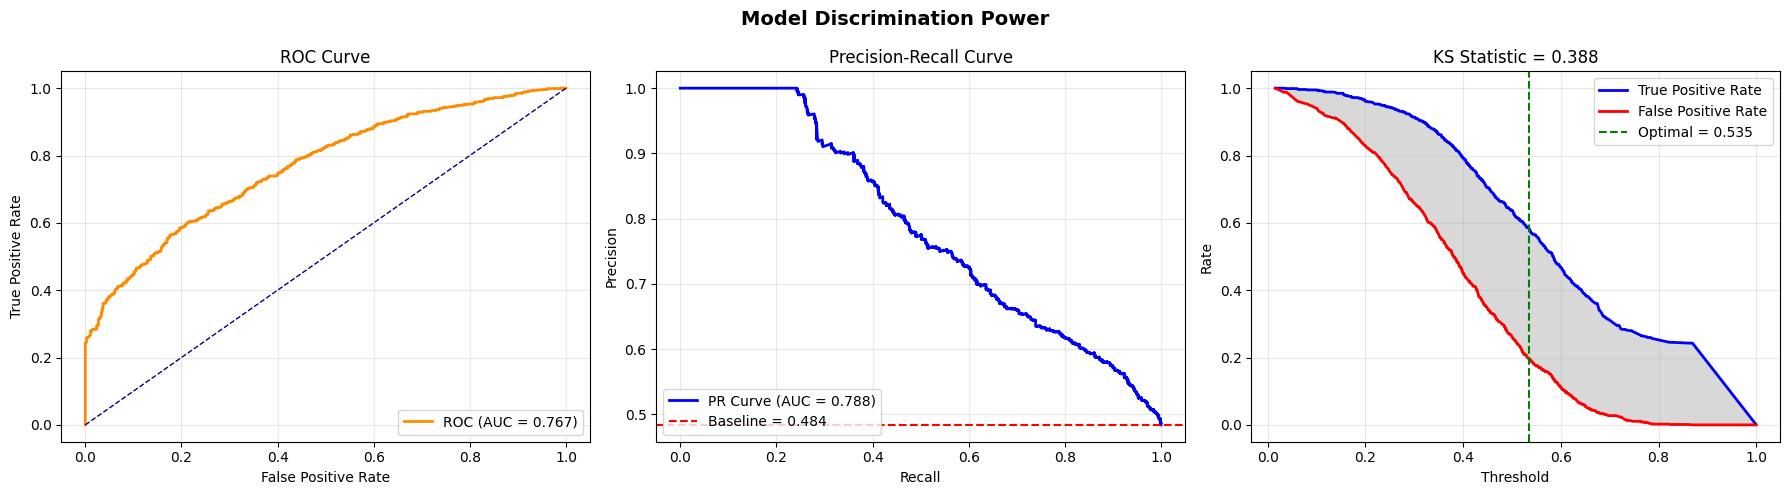

• ROC-AUC: 0.7667
• PR-AUC: 0.7877
• KS Statistic: 0.388 (MODERATE discrimination)
• Optimal Threshold: 0.535

💼 STEP 2: BUSINESS IMPACT
----------------------------------------
Verification of decile assignment:
Decile 1 mean prob: 0.998
Decile 10 mean prob: 0.121


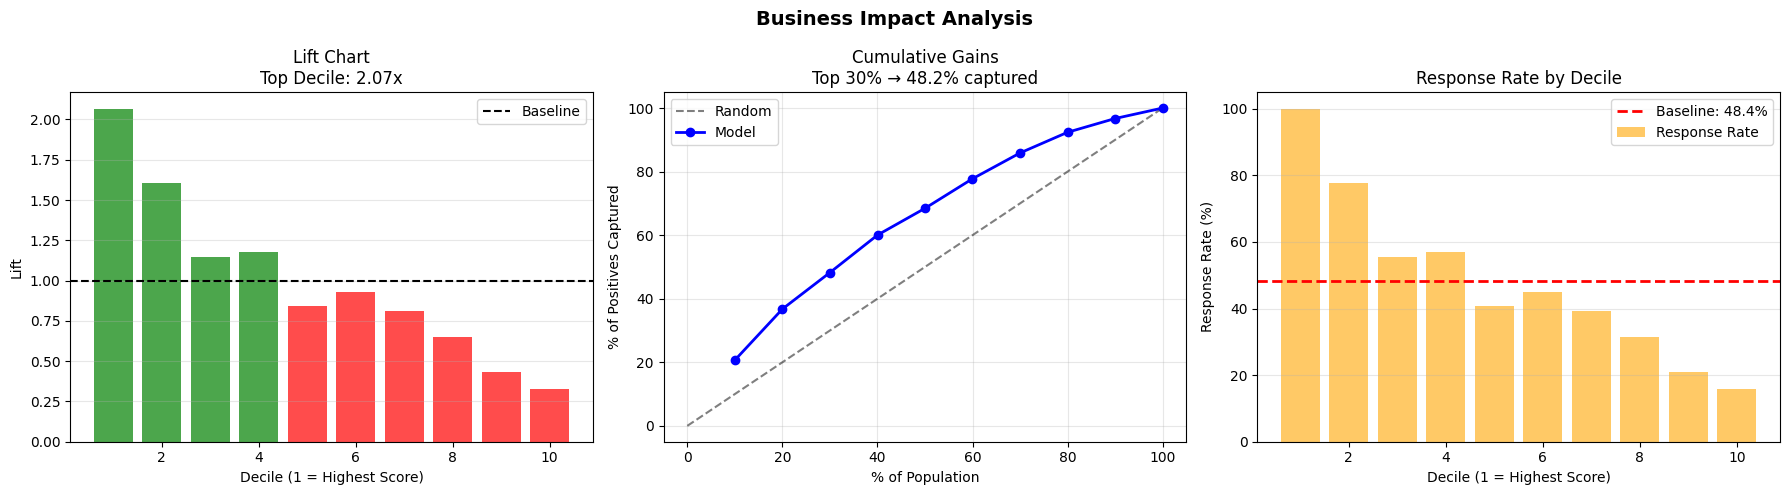

• Top Decile Lift: 0.33x
• Top 30% captures: 48.2% of positives
• Baseline response rate: 48.4%
• Top decile response: 100.0%

📈 STEP 4: CONFUSION MATRIX
----------------------------------------


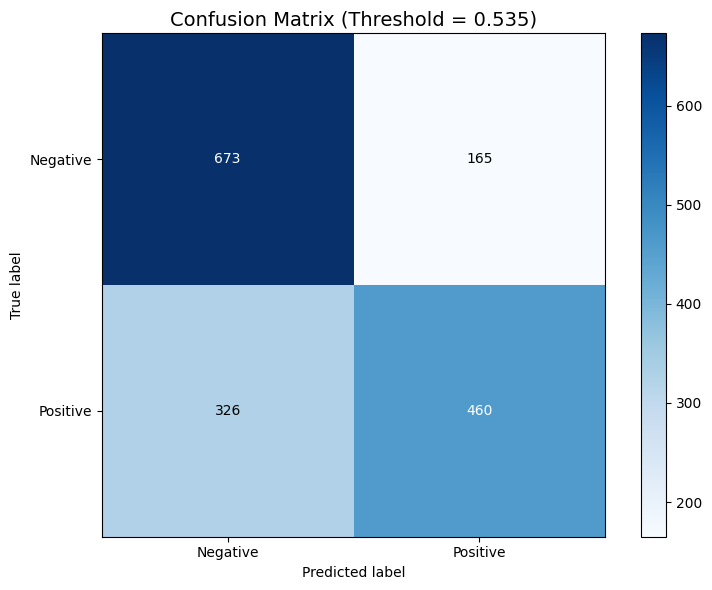

At threshold 0.535:
• Accuracy: 0.698
• Precision: 0.736
• Recall: 0.585
• F1-Score: 0.652
• True Positives: 460
• False Positives: 165
• True Negatives: 673
• False Negatives: 326

FINAL VALIDATION SUMMARY

✅ DISCRIMINATION POWER:
   KS Statistic: 0.388 (MODERATE discrimination)

✅ BUSINESS VALUE:
   Efficiency: 0.33x better than random
   Coverage: Top 30% → 48.2% captured

✅ MODEL QUALITY:
   ROC-AUC: 0.7667 (Excellent if >0.8)
   PR-AUC: 0.7877 (Excellent if >0.7)

✅ OPERATIONAL METRICS:
   Optimal Threshold: 0.535
   Precision at threshold: 0.736
   Recall at threshold: 0.585

🔍 FEATURE IMPORTANCE - SUBPOPULATION MODEL

Top 20 Features:
                         feature  importance
176      quote_consistency_score    0.102690
165             is_quick_decider    0.042690
247       price_x_sophistication    0.022603
301             max_price_bin_10    0.017974
212       speed_complexity_ratio    0.015822
52       equipment_variety_count    0.015718
148                    max_price   

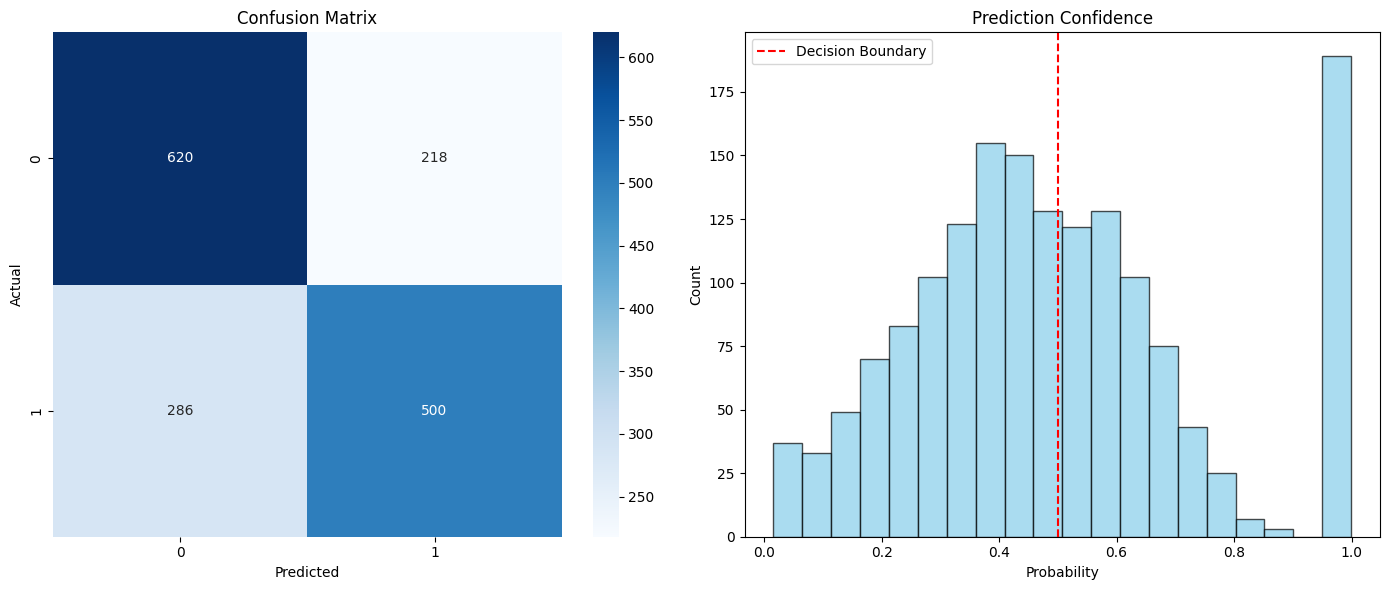

In [4]:
#with redirect_stdout(open('/dev/null', 'w')):
result = run_pipeline(df_quotes)

run_model_error_analysis(result['X_test'], result['y_test'], result['model'])